# Lecture 02 — Linear Regression & Regularization

**Learning objectives**

- Formulate linear regression, derive the least-squares solution via the normal equations, and interpret it geometrically as an orthogonal projection.
- Justify the squared loss probabilistically: maximum likelihood under Gaussian noise.
- Implement linear regression from scratch three ways — closed form, batch gradient descent, mini-batch SGD — and verify against scikit-learn on the diabetes dataset.
- Explain why feature scaling matters for gradient-based training (conditioning).
- Use polynomial features, recognize overfitting, and derive and simulate the bias–variance decomposition.
- Derive Ridge regression (closed form and MAP with a Gaussian prior), Lasso (sparsity, soft-thresholding, coordinate descent) and ElasticNet, and read regularization paths.
- Evaluate regression models with MSE, RMSE, MAE and $R^2$.

**Prerequisites**

- [`00_course_introduction_and_python_toolkit.ipynb`](00_course_introduction_and_python_toolkit.ipynb) (risk, ERM, scikit-learn API).
- [`01_mathematical_foundations.ipynb`](01_mathematical_foundations.ipynb) (matrix calculus, SVD, Gaussian MLE/MAP, gradient descent and conditioning).

**Contents**

1. The linear model and least squares
2. The probabilistic view: Gaussian noise and MLE
3. From scratch: closed form, batch GD, mini-batch SGD
4. Feature scaling and conditioning
5. Regression metrics
6. Polynomial features and overfitting
7. The bias–variance decomposition
8. Ridge regression
9. Lasso regression
10. ElasticNet
11. Pitfalls & practical tips
12. Exercises
13. Summary and further reading

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LassoCV, lasso_path, enet_path
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.exceptions import ConvergenceWarning

%matplotlib inline
plt.rcParams["figure.figsize"] = (7, 4.5)
np.random.seed(42)
rng = np.random.default_rng(42)
np.set_printoptions(precision=4, suppress=True)

## 1. The linear model and least squares

### 1.1 Model

Given inputs $x\in\mathbb{R}^d$ and a real target $y$, linear regression uses the hypothesis class
$$h_{w,b}(x) = w^\top x + b = \sum_{j=1}^d w_j x_j + b .$$
Absorbing the intercept by appending a constant feature, $\tilde x = (1, x_1,\dots,x_d)^\top$ and $\theta = (b, w)$, the
predictions for all $n$ training points are $\hat y = X\theta$ with design matrix $X\in\mathbb{R}^{n\times(d+1)}$.
"Linear" refers to linearity **in the parameters**: $x$ may be replaced by any fixed feature map $\phi(x)$
(polynomials, splines, interactions) and everything below still applies.

### 1.2 Least squares and the normal equations

ERM with the squared loss minimizes the residual sum of squares
$$J(\theta) = \|y - X\theta\|_2^2 = (y-X\theta)^\top(y-X\theta) = y^\top y - 2\theta^\top X^\top y + \theta^\top X^\top X\theta .$$
Using $\nabla_\theta(a^\top\theta)=a$ and $\nabla_\theta(\theta^\top A\theta) = 2A\theta$ for symmetric $A$ (Lecture 01):
$$\nabla_\theta J = -2X^\top y + 2X^\top X\theta = -2X^\top(y - X\theta).$$
Setting it to zero yields the **normal equations**
$$X^\top X\,\hat\theta = X^\top y \qquad\Longrightarrow\qquad \hat\theta = (X^\top X)^{-1}X^\top y\quad\text{if } X \text{ has full column rank}.$$
The Hessian $\nabla^2 J = 2X^\top X\succeq 0$, so $J$ is convex and any solution of the normal equations is a global
minimum; it is unique iff $X^\top X$ is invertible (no perfectly collinear features, $n\ge d+1$). Otherwise the
minimum-norm solution is $\hat\theta = X^+y$ via the SVD pseudo-inverse.

**Geometry.** The normal equations say $X^\top(y - X\hat\theta)=0$: the residual is **orthogonal to the column space**
of $X$. Thus $\hat y = X\hat\theta = Hy$ with the "hat" matrix $H = X(X^\top X)^{-1}X^\top$, an orthogonal projection
($H^2=H$, $H^\top=H$) onto $\operatorname{col}(X)$.

**Computation.** Forming $X^\top X$ squares the condition number; in practice one uses a QR decomposition or SVD
(`np.linalg.lstsq`), costing $O(nd^2)$. Gradient methods (Section 3) cost $O(nd)$ per iteration and scale to huge $n$.

### 1.3 Data: the diabetes dataset

442 patients, 10 baseline variables (age, sex, BMI, blood pressure, six blood-serum measurements), target = a
quantitative measure of disease progression one year later. We load the **unscaled** version to study scaling explicitly.

In [2]:
diab = load_diabetes(scaled=False)
X_raw, y = diab.data, diab.target
feature_names = diab.feature_names
print("X:", X_raw.shape, "| y range:", y.min(), "-", y.max())
pd.DataFrame(X_raw, columns=feature_names).describe().loc[["mean", "std", "min", "max"]].round(2)

X: (442, 10) | y range: 25.0 - 346.0


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
mean,48.52,1.47,26.38,94.65,189.14,115.44,49.79,4.07,4.64,91.26
std,13.11,0.50,4.42,13.83,34.61,30.41,12.93,1.29,0.52,11.50
min,19.00,1.00,18.00,62.00,97.00,41.60,22.00,2.00,3.26,58.00
max,79.00,2.00,42.20,133.00,301.00,242.40,99.00,9.09,6.11,124.00


In [3]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_raw, y, test_size=0.25, random_state=42)
scaler = StandardScaler().fit(X_train_raw)                 # statistics from the training split only
X_train = scaler.transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

def add_bias(X):
    return np.column_stack([np.ones(len(X)), X])

Xb_train, Xb_test = add_bias(X_train), add_bias(X_test)
print("design matrix with bias column:", Xb_train.shape)

design matrix with bias column: (331, 11)


## 2. The probabilistic view: Gaussian noise and MLE

Assume the data are generated as
$$y_i = \theta^\top x_i + \varepsilon_i,\qquad \varepsilon_i\overset{\text{iid}}{\sim}\mathcal{N}(0,\sigma^2),
\qquad\text{i.e.}\qquad p(y_i\mid x_i,\theta) = \mathcal{N}(y_i\mid\theta^\top x_i,\sigma^2).$$
The conditional log-likelihood of the sample is
$$\ell(\theta,\sigma^2) = \sum_{i=1}^n\log\mathcal{N}(y_i\mid\theta^\top x_i,\sigma^2)
= -\frac n2\log(2\pi\sigma^2) - \frac{1}{2\sigma^2}\sum_{i=1}^n (y_i - \theta^\top x_i)^2 .$$
For any fixed $\sigma^2$, maximizing over $\theta$ is **exactly** minimizing the sum of squared residuals:
$$\hat\theta_{\text{MLE}} = \arg\min_\theta \|y - X\theta\|^2 = \hat\theta_{\text{OLS}}.$$
Maximizing over $\sigma^2$ (as in Lecture 01) gives $\hat\sigma^2_{\text{MLE}} = \frac1n\|y-X\hat\theta\|^2$, the mean
squared residual (biased; the unbiased estimator divides by $n-d-1$).

Consequences:

- Squared loss is the natural loss when noise is Gaussian; heavy-tailed noise (e.g. Laplace) would lead to the absolute loss (MAE) instead.
- Under this model $\hat\theta\sim\mathcal{N}\big(\theta, \sigma^2(X^\top X)^{-1}\big)$, giving standard errors and confidence intervals. The **Gauss–Markov theorem** states that OLS is the best linear unbiased estimator even without Gaussianity (only zero-mean, uncorrelated, homoscedastic noise is needed).

## 3. From scratch: closed form, batch GD, mini-batch SGD

### 3.1 Closed form

We solve the normal equations with `np.linalg.solve` (fine for $d=11$) and with `lstsq` (SVD-based, more robust),
and compare with `sklearn.linear_model.LinearRegression`.

In [4]:
# (a) normal equations
theta_ne = np.linalg.solve(Xb_train.T @ Xb_train, Xb_train.T @ y_train)
# (b) SVD-based least squares
theta_ls, *_ = np.linalg.lstsq(Xb_train, y_train, rcond=None)
# (c) scikit-learn (fits the intercept separately)
lr = LinearRegression().fit(X_train, y_train)
theta_sk = np.r_[lr.intercept_, lr.coef_]

print("max |normal eq - lstsq|  :", np.abs(theta_ne - theta_ls).max())
print("max |normal eq - sklearn|:", np.abs(theta_ne - theta_sk).max())
pd.DataFrame({"normal eq.": theta_ne, "lstsq": theta_ls, "sklearn": theta_sk},
             index=["intercept"] + feature_names).round(3).T

max |normal eq - lstsq|  : 8.29558643999917e-13
max |normal eq - sklearn|: 5.186961971048731e-13


,intercept,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
normal eq.,154.344,2.215,-11.514,25.077,18.249,-44.145,24.514,5.498,13.007,33.38,1.248
lstsq,154.344,2.215,-11.514,25.077,18.249,-44.145,24.514,5.498,13.007,33.38,1.248
sklearn,154.344,2.215,-11.514,25.077,18.249,-44.145,24.514,5.498,13.007,33.38,1.248


In [5]:
# Orthogonality of residuals and properties of the hat matrix
resid = y_train - Xb_train @ theta_ne
print("max |X^T r| (should be ~0):", np.abs(Xb_train.T @ resid).max())
H = Xb_train @ np.linalg.solve(Xb_train.T @ Xb_train, Xb_train.T)
print("H idempotent:", np.allclose(H @ H, H), "| symmetric:", np.allclose(H, H.T), "| trace(H) = #params =", round(np.trace(H), 6))
sigma2_mle = np.mean(resid**2); sigma2_unb = resid @ resid / (len(y_train) - Xb_train.shape[1])
print(f"noise variance: MLE {sigma2_mle:.1f}, unbiased {sigma2_unb:.1f}")
# Standard errors from sigma^2 (X^T X)^{-1}
se = np.sqrt(np.diag(sigma2_unb * np.linalg.inv(Xb_train.T @ Xb_train)))
print("t-statistics |theta/se| :", {k: round(float(v), 1) for k, v in zip(["b"] + feature_names, np.abs(theta_ne / se))})

max |X^T r| (should be ~0): 1.2710375433100294e-11
H idempotent: True | symmetric: True | trace(H) = #params = 11.0
noise variance: MLE 2907.3, unbiased 3007.2
t-statistics |theta/se| : {'b': 51.2, 'age': 0.7, 'sex': 3.4, 'bmi': 6.7, 'bp': 5.1, 's1': 2.0, 's2': 1.4, 's3': 0.5, 's4': 1.4, 's5': 3.5, 's6': 0.3}


### 3.2 Batch gradient descent

Using the averaged objective $J(\theta) = \frac{1}{2n}\|X\theta - y\|^2$ (same minimizer, nicer scaling),
$$\nabla J(\theta) = \frac1n X^\top(X\theta - y),\qquad \theta_{t+1} = \theta_t - \eta\,\frac1n X^\top(X\theta_t - y).$$
$J$ is a quadratic with Hessian $\frac1n X^\top X$; from Lecture 01, GD converges iff $\eta < 2/L$ with
$L = \lambda_{\max}(\tfrac1n X^\top X)$, and the rate depends on $\kappa = \lambda_{\max}/\lambda_{\min}$. We use $\eta = 1/L$.
Each iteration costs $O(nd)$.

In [6]:
def mse_half(theta, X, y):
    r = X @ theta - y
    return 0.5 * np.mean(r**2)

def batch_gd(X, y, lr, n_iters):
    theta = np.zeros(X.shape[1])
    history = [mse_half(theta, X, y)]
    for _ in range(n_iters):
        grad = X.T @ (X @ theta - y) / len(y)        # full-batch gradient
        theta -= lr * grad
        history.append(mse_half(theta, X, y))
    return theta, np.array(history)

eigs = np.linalg.eigvalsh(Xb_train.T @ Xb_train / len(y_train))
L = eigs.max()
print(f"L = lambda_max = {L:.3f}, lambda_min = {eigs.min():.4f}, condition number = {L/eigs.min():.1f}")
theta_gd, hist_gd = batch_gd(Xb_train, y_train, lr=1 / L, n_iters=3000)
print("max |theta_GD - theta_closed_form|:", np.abs(theta_gd - theta_ne).max().round(6))

L = lambda_max = 3.919, lambda_min = 0.0094, condition number = 417.8


max |theta_GD - theta_closed_form|:

 0.030573


### 3.3 Mini-batch stochastic gradient descent

With a random mini-batch $B$ of size $m$ the gradient estimate $\frac1m X_B^\top(X_B\theta - y_B)$ is unbiased. Each
epoch shuffles the data and sweeps through it in $\lceil n/m\rceil$ steps. We use a step size that decays as
$\eta_t = \eta_0/(1 + t/\tau)$ to get past the noise floor (Lecture 01, Section 5.3).

max |theta_SGD - theta_closed_form|: 22.157 | RMS difference of training predictions: 3.016
J*: 1453.629 | J(GD): 1453.629 | J(SGD): 1458.178


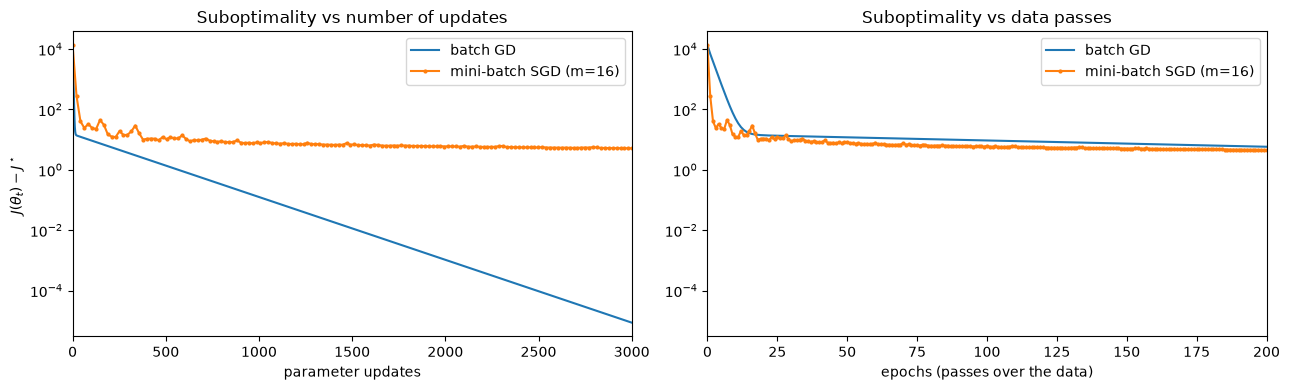

In [7]:
def minibatch_sgd(X, y, lr0, batch_size, n_epochs, tau=200, seed=0):
    r = np.random.default_rng(seed)
    n = len(y); theta = np.zeros(X.shape[1]); t = 0
    history = [mse_half(theta, X, y)]
    for epoch in range(n_epochs):
        perm = r.permutation(n)
        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]
            grad = X[idx].T @ (X[idx] @ theta - y[idx]) / len(idx)
            theta -= lr0 / (1 + t / tau) * grad
            t += 1
        history.append(mse_half(theta, X, y))        # record once per epoch
    return theta, np.array(history)

theta_sgd, hist_sgd = minibatch_sgd(Xb_train, y_train, lr0=0.1, batch_size=16, n_epochs=200)
J_star = mse_half(theta_ne, Xb_train, y_train)
print("max |theta_SGD - theta_closed_form|:", np.abs(theta_sgd - theta_ne).max().round(3),
      "| RMS difference of training predictions:", np.sqrt(np.mean((Xb_train @ (theta_sgd - theta_ne))**2)).round(3))
print(f"J*: {J_star:.3f} | J(GD): {hist_gd[-1]:.3f} | J(SGD): {hist_sgd[-1]:.3f}")

n_batches = int(np.ceil(len(y_train) / 16))
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].semilogy(hist_gd - J_star + 1e-10, label="batch GD")
axes[0].semilogy(np.arange(len(hist_sgd)) * n_batches, hist_sgd - J_star + 1e-10, "o-", ms=2, label="mini-batch SGD (m=16)")
axes[0].set_xlabel("parameter updates"); axes[0].set_ylabel(r"$J(\theta_t)-J^\star$"); axes[0].set_xlim(0, 3000)
axes[0].legend(); axes[0].set_title("Suboptimality vs number of updates")
axes[1].semilogy(np.arange(len(hist_gd)), hist_gd - J_star + 1e-10, label="batch GD")
axes[1].semilogy(np.arange(len(hist_sgd)), hist_sgd - J_star + 1e-10, "o-", ms=2, label="mini-batch SGD (m=16)")
axes[1].set_xlabel("epochs (passes over the data)"); axes[1].set_xlim(0, 200)
axes[1].legend(); axes[1].set_title("Suboptimality vs data passes")
plt.tight_layout(); plt.show()

Per **epoch** (i.e. per unit of computation), SGD makes far more progress early on, because it performs $\approx 21$
updates per pass instead of one. Its final accuracy is limited by gradient noise, which is irrelevant in practice
because statistical error ($\sim 1/n$) dominates optimization error long before. Batch GD converges linearly at a rate
governed by the condition number.

Notice also that SGD's *parameters* can still be far from $\hat\theta$ while its *loss* and predictions are almost
optimal: the features `s1` and `s2` (total and LDL cholesterol) are strongly correlated, so the Hessian has a tiny
eigenvalue ($\lambda_{\min}\approx 0.009$) and the loss is nearly flat along the direction that trades one
coefficient against the other. Parameters in such directions are poorly determined by the data — a first hint of why
regularization (Section 8) helps.

## 4. Feature scaling and conditioning

The raw diabetes features have very different scales (age in years, sex coded 1/2, serum values in the hundreds).
The curvature of $J$ along direction $j$ is $\propto$ the variance of feature $j$, so the Hessian $\frac1nX^\top X$ is
badly **ill-conditioned** and GD — whose largest usable step is set by the steepest direction — crawls along the flat ones.

**Standardization** $x_j\mapsto(x_j-\mu_j)/\sigma_j$ equalizes curvature per feature (the remaining conditioning comes
from correlations between features). It does not change the OLS predictions (the model class is invariant to affine
feature maps), but it **does** change regularized solutions (Ridge/Lasso penalize all coefficients equally, so features
must be on comparable scales).

raw features : condition number of Hessian = 4.890e+07
standardized : condition number of Hessian = 4.178e+02


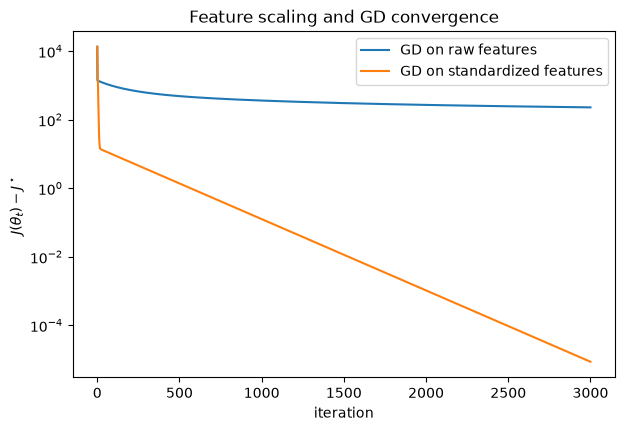

OLS predictions equal (raw vs scaled): True


In [8]:
Xb_train_raw = add_bias(X_train_raw)
for name, Xd in [("raw features", Xb_train_raw), ("standardized", Xb_train)]:
    e = np.linalg.eigvalsh(Xd.T @ Xd / len(Xd))
    print(f"{name:13s}: condition number of Hessian = {e.max()/e.min():.3e}")

theta_raw_star = np.linalg.lstsq(Xb_train_raw, y_train, rcond=None)[0]
J_raw_star = mse_half(theta_raw_star, Xb_train_raw, y_train)
L_raw = np.linalg.eigvalsh(Xb_train_raw.T @ Xb_train_raw / len(y_train)).max()
_, hist_raw = batch_gd(Xb_train_raw, y_train, lr=1 / L_raw, n_iters=3000)

plt.semilogy(hist_raw - J_raw_star + 1e-10, label="GD on raw features")
plt.semilogy(hist_gd - J_star + 1e-10, label="GD on standardized features")
plt.xlabel("iteration"); plt.ylabel(r"$J(\theta_t)-J^\star$"); plt.legend(); plt.title("Feature scaling and GD convergence")
plt.show()

# Predictions of OLS are identical with or without scaling:
print("OLS predictions equal (raw vs scaled):", np.allclose(Xb_train_raw @ theta_raw_star, Xb_train @ theta_ne))

## 5. Regression metrics

For predictions $\hat y_i$ on a held-out set of size $n$:

| Metric | Definition | Notes |
|---|---|---|
| MSE | $\frac1n\sum_i (y_i-\hat y_i)^2$ | Matches the training loss; squared units; sensitive to outliers |
| RMSE | $\sqrt{\text{MSE}}$ | Same units as $y$ |
| MAE | $\frac1n\sum_i \lvert y_i-\hat y_i\rvert$ | Robust to outliers; optimal constant predictor is the median |
| $R^2$ | $1 - \frac{\sum_i (y_i-\hat y_i)^2}{\sum_i (y_i-\bar y)^2}$ | Fraction of variance explained; 1 is perfect, 0 = predicting the mean, **can be negative** on test data |

Adjusted $R^2 = 1-(1-R^2)\frac{n-1}{n-d-1}$ penalizes the number of features $d$ (training-set use only).
Note that on the training set $R^2$ never decreases when adding features — another manifestation of optimistic bias.

      from scratch   sklearn  train (from scratch)
MSE       2848.311  2848.311              2907.258
RMSE        53.370    53.370                53.919
MAE         41.549    41.549                44.055
R2           0.485     0.485                 0.519
baseline (predict train mean) test RMSE: 74.88


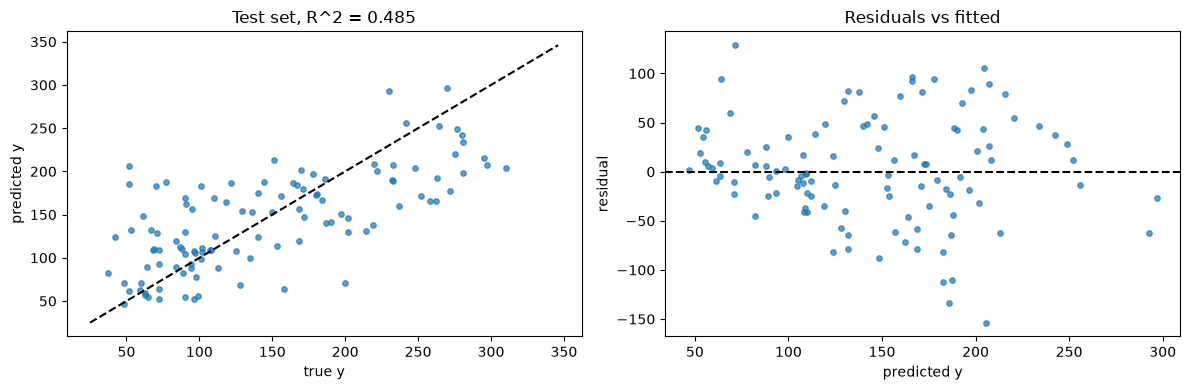

In [9]:
def metrics(y, yhat):
    err = y - yhat
    mse = np.mean(err**2)
    return {"MSE": mse, "RMSE": np.sqrt(mse), "MAE": np.mean(np.abs(err)),
            "R2": 1 - np.sum(err**2) / np.sum((y - y.mean())**2)}

yhat_test = Xb_test @ theta_ne
ours = metrics(y_test, yhat_test)
sk = {"MSE": mean_squared_error(y_test, yhat_test), "RMSE": np.sqrt(mean_squared_error(y_test, yhat_test)),
      "MAE": mean_absolute_error(y_test, yhat_test), "R2": r2_score(y_test, yhat_test)}
print(pd.DataFrame({"from scratch": ours, "sklearn": sk, "train (from scratch)": metrics(y_train, Xb_train @ theta_ne)}).round(3))
print("baseline (predict train mean) test RMSE:", np.sqrt(np.mean((y_test - y_train.mean())**2)).round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_test, yhat_test, s=15, alpha=0.7); axes[0].plot([25, 346], [25, 346], "k--")
axes[0].set_xlabel("true y"); axes[0].set_ylabel("predicted y"); axes[0].set_title(f"Test set, R^2 = {ours['R2']:.3f}")
axes[1].scatter(yhat_test, y_test - yhat_test, s=15, alpha=0.7); axes[1].axhline(0, color="k", ls="--")
axes[1].set_xlabel("predicted y"); axes[1].set_ylabel("residual"); axes[1].set_title("Residuals vs fitted")
plt.tight_layout(); plt.show()

## 6. Polynomial features and overfitting

A linear model on the feature map $\phi(x) = (1, x, x^2,\dots,x^p)$ fits degree-$p$ polynomials. Larger $p$ enlarges the
hypothesis class. We use a synthetic 1-D problem where the truth is known,
$$y = \sin(2\pi x) + \varepsilon,\quad x\sim\mathcal{U}[0,1],\ \varepsilon\sim\mathcal{N}(0, 0.3^2),$$
with only $n=15$ training points (Bishop's classic example).

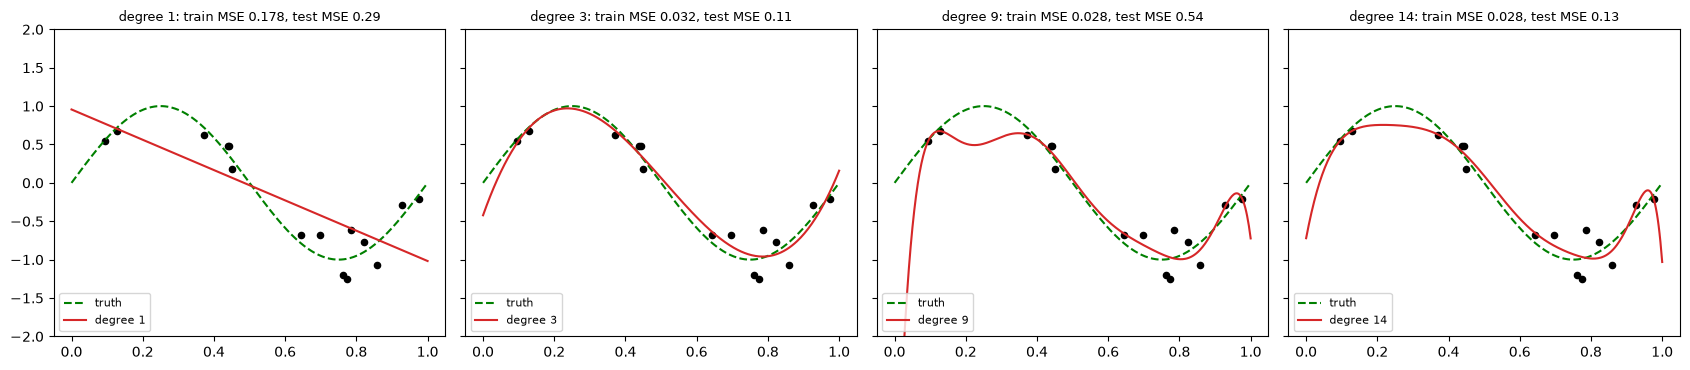

In [10]:
f_true = lambda x: np.sin(2 * np.pi * x)
noise_sd = 0.3
def make_data(n, r):
    x = r.uniform(0, 1, n)
    return x, f_true(x) + r.normal(0, noise_sd, n)

x_tr, y_tr = make_data(15, rng)
x_te, y_te = make_data(1000, rng)
grid = np.linspace(0, 1, 400)

def poly_model(degree, alpha=None):
    reg = LinearRegression() if alpha is None else Ridge(alpha=alpha)
    return make_pipeline(PolynomialFeatures(degree, include_bias=False), StandardScaler(), reg)

fig, axes = plt.subplots(1, 4, figsize=(17, 3.8), sharey=True)
for ax, deg in zip(axes, [1, 3, 9, 14]):
    m = poly_model(deg).fit(x_tr[:, None], y_tr)
    ax.plot(grid, f_true(grid), "g--", label="truth")
    ax.plot(grid, m.predict(grid[:, None]), "C3", label=f"degree {deg}")
    ax.scatter(x_tr, y_tr, s=20, color="k")
    tr = np.mean((m.predict(x_tr[:, None]) - y_tr)**2); te = np.mean((m.predict(x_te[:, None]) - y_te)**2)
    ax.set_title(f"degree {deg}: train MSE {tr:.3f}, test MSE {te:.2f}", fontsize=9)
    ax.set_ylim(-2, 2); ax.legend(loc="lower left", fontsize=8)
plt.tight_layout(); plt.show()

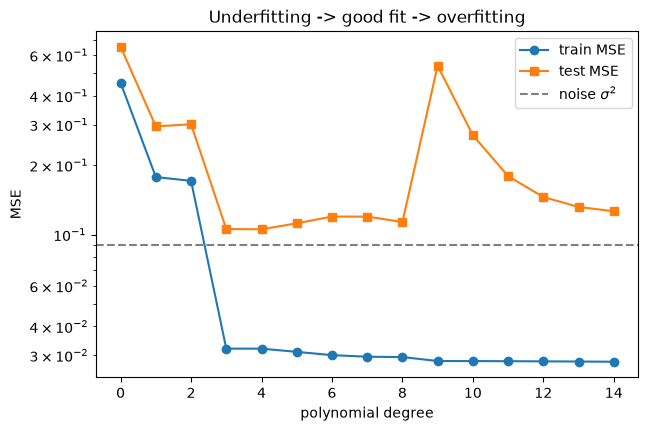

Coefficient magnitudes of the degree-9 fit (standardized features): [  38.  406. 1864. 4294. 4471.  149. 4921. 4330. 1232.]


In [11]:
degrees = np.arange(0, 15)
tr_err, te_err = [], []
for deg in degrees:
    if deg == 0:
        pred_tr = np.full_like(y_tr, y_tr.mean()); pred_te = np.full_like(y_te, y_tr.mean())
    else:
        m = poly_model(deg).fit(x_tr[:, None], y_tr)
        pred_tr, pred_te = m.predict(x_tr[:, None]), m.predict(x_te[:, None])
    tr_err.append(np.mean((pred_tr - y_tr)**2)); te_err.append(np.mean((pred_te - y_te)**2))
plt.semilogy(degrees, tr_err, "o-", label="train MSE")
plt.semilogy(degrees, te_err, "s-", label="test MSE")
plt.axhline(noise_sd**2, color="gray", ls="--", label=r"noise $\sigma^2$")
plt.xlabel("polynomial degree"); plt.ylabel("MSE"); plt.legend(); plt.title("Underfitting -> good fit -> overfitting")
plt.show()
m9 = poly_model(9).fit(x_tr[:, None], y_tr)
print("Coefficient magnitudes of the degree-9 fit (standardized features):", np.abs(m9[-1].coef_).round(0))

The overfitted polynomials interpolate the noise with **huge coefficients** that cancel each other — the motivation
for penalizing coefficient size (Ridge, Section 8).

## 7. The bias–variance decomposition

### 7.1 Derivation

Let $y = f(x) + \varepsilon$ with $\mathbb{E}[\varepsilon]=0$, $\mathrm{Var}[\varepsilon]=\sigma^2$, and let
$\hat f_S$ be the model fitted on a random training set $S$. Fix a test input $x$ and write $\bar f(x) = \mathbb{E}_S[\hat f_S(x)]$.
The expected squared error of a fresh test label (expectation over $S$ and the test noise $\varepsilon$, which are independent):
$$
\begin{aligned}
\mathbb{E}\big[(y - \hat f_S(x))^2\big]
&= \mathbb{E}\big[(f(x) + \varepsilon - \hat f_S(x))^2\big] \\
&= \sigma^2 + \mathbb{E}_S\big[(f(x) - \hat f_S(x))^2\big] \qquad(\text{cross term } 2\,\mathbb{E}[\varepsilon]\,\mathbb{E}[\cdot]=0)\\
&= \sigma^2 + \mathbb{E}_S\big[(f(x) - \bar f(x) + \bar f(x) - \hat f_S(x))^2\big] \\
&= \underbrace{\sigma^2}_{\text{irreducible noise}} + \underbrace{\big(f(x) - \bar f(x)\big)^2}_{\text{bias}^2} + \underbrace{\mathbb{E}_S\big[(\hat f_S(x) - \bar f(x))^2\big]}_{\text{variance}},
\end{aligned}
$$
where the last cross term vanishes because $\mathbb{E}_S[\bar f(x) - \hat f_S(x)] = 0$. Averaging over $x\sim p(x)$ gives
the decomposition of the expected test MSE.

- **Bias**: error of the *average* model — how far the hypothesis class (plus fitting procedure) is from the truth.
- **Variance**: how much the fitted model fluctuates with the particular training sample.
- Flexible models: low bias, high variance. Rigid models: high bias, low variance. Regularization moves along this trade-off.

### 7.2 Simulation

We draw 300 independent training sets of size 25, fit each polynomial degree (and, separately, Ridge with varying
$\alpha$ on degree-12 features), and estimate bias$^2$ and variance on a grid of test inputs.

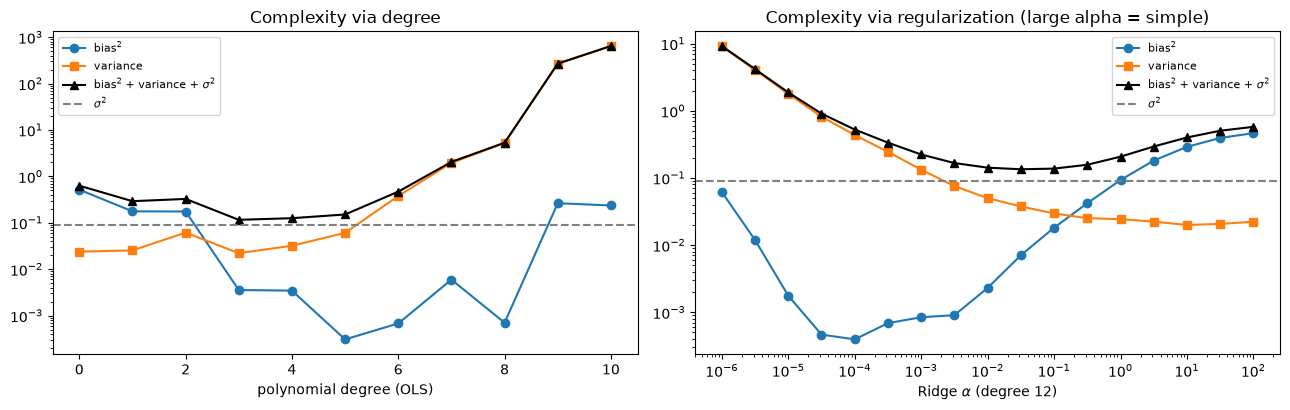

best degree by expected test MSE: 3


In [12]:
def poly_design(x, degree):
    # Features: scaled monomials of u = 2x-1 in [-1,1] (better conditioned than raw x)
    u = 2 * x - 1
    return np.vander(u, degree + 1, increasing=True)

def bias_variance(fit_predict, n_sets=300, n=25, seed=1):
    r = np.random.default_rng(seed)
    x_eval = np.linspace(0.02, 0.98, 100)
    preds = np.empty((n_sets, len(x_eval)))
    for s in range(n_sets):
        xs, ys = make_data(n, r)
        preds[s] = fit_predict(xs, ys, x_eval)
    fbar = preds.mean(0)
    bias2 = np.mean((fbar - f_true(x_eval))**2)
    var = np.mean(preds.var(0))
    return bias2, var

def ols_poly(degree):
    def fp(xs, ys, xe):
        th = np.linalg.lstsq(poly_design(xs, degree), ys, rcond=None)[0]
        return poly_design(xe, degree) @ th
    return fp

def ridge_poly(degree, lam):
    def fp(xs, ys, xe):
        P = poly_design(xs, degree); I = np.eye(degree + 1); I[0, 0] = 0      # do not penalize the intercept
        th = np.linalg.solve(P.T @ P + lam * I, P.T @ ys)
        return poly_design(xe, degree) @ th
    return fp

bv_deg = np.array([bias_variance(ols_poly(d)) for d in range(0, 11)])
lams = np.logspace(-6, 2, 17)
bv_lam = np.array([bias_variance(ridge_poly(12, l)) for l in lams])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, xs_, bv, xl in [(axes[0], np.arange(0, 11), bv_deg, "polynomial degree (OLS)"),
                        (axes[1], lams, bv_lam, r"Ridge $\alpha$ (degree 12)")]:
    ax.plot(xs_, bv[:, 0], "o-", label=r"bias$^2$")
    ax.plot(xs_, bv[:, 1], "s-", label="variance")
    ax.plot(xs_, bv.sum(1) + noise_sd**2, "k^-", label=r"bias$^2$ + variance + $\sigma^2$")
    ax.axhline(noise_sd**2, color="gray", ls="--", label=r"$\sigma^2$")
    ax.set_yscale("log"); ax.set_xlabel(xl); ax.legend(fontsize=8)
axes[1].set_xscale("log")
axes[0].set_title("Complexity via degree"); axes[1].set_title("Complexity via regularization (large alpha = simple)")
plt.tight_layout(); plt.show()
best = np.argmin(bv_deg.sum(1)); print(f"best degree by expected test MSE: {best}")

In [13]:
# Sanity check of the decomposition: directly estimate the expected test MSE for degree 3 and compare
r = np.random.default_rng(7); deg = 3; mses = []
for s in range(300):
    xs, ys = make_data(25, r); xe, ye = make_data(200, r)
    mses.append(np.mean((ols_poly(deg)(xs, ys, xe) - ye)**2))
b2, v = bias_variance(ols_poly(deg))
print(f"direct E[test MSE] = {np.mean(mses):.4f}  vs  bias^2 + var + sigma^2 = {b2 + v + noise_sd**2:.4f}")
print("(small differences: the decomposition was evaluated on a grid in [0.02, 0.98] rather than x ~ U[0,1])")

direct E[test MSE] = 0.1131  vs  bias^2 + var + sigma^2 = 0.1157
(small differences: the decomposition was evaluated on a grid in [0.02, 0.98] rather than x ~ U[0,1])


## 8. Ridge regression

### 8.1 Closed form

Ridge adds an $\ell_2$ penalty on the weights (not the intercept):
$$J_{\text{ridge}}(w) = \|y - Xw\|_2^2 + \alpha\|w\|_2^2 .$$
With centred $X$ and $y$ (so the intercept is $\hat b = \bar y - \bar x^\top\hat w$), the gradient is
$-2X^\top(y-Xw) + 2\alpha w$; setting it to zero:
$$(X^\top X + \alpha I)\,\hat w_{\text{ridge}} = X^\top y\qquad\Longrightarrow\qquad \hat w_{\text{ridge}} = (X^\top X+\alpha I)^{-1}X^\top y .$$
For $\alpha>0$ the matrix $X^\top X+\alpha I$ has eigenvalues $\ge\alpha$, so it is **always invertible** (even with
$d>n$ or collinear features) and better conditioned. Via the SVD $X=U\Sigma V^\top$:
$$\hat w_{\text{ridge}} = \sum_{j} \frac{\sigma_j}{\sigma_j^2 + \alpha}\,(u_j^\top y)\,v_j ,
\qquad X\hat w_{\text{ridge}} = \sum_j \underbrace{\frac{\sigma_j^2}{\sigma_j^2+\alpha}}_{\text{shrinkage factor}}(u_j^\top y)\,u_j .$$
Directions with small singular values (low-variance, poorly determined) are shrunk the most. The **effective degrees
of freedom** $\mathrm{df}(\alpha) = \sum_j \sigma_j^2/(\sigma_j^2+\alpha)$ decrease from $d$ to 0 as $\alpha$ grows.

### 8.2 Ridge as MAP estimation

Keep the Gaussian likelihood $y\mid X,w\sim\mathcal{N}(Xw,\sigma^2 I)$ and put a Gaussian prior $w\sim\mathcal{N}(0,\tau^2 I)$. Then
$$-\log p(w\mid X, y) = \frac{1}{2\sigma^2}\|y - Xw\|^2 + \frac{1}{2\tau^2}\|w\|^2 + \text{const},$$
so $\hat w_{\text{MAP}} = \hat w_{\text{ridge}}$ with $\alpha = \sigma^2/\tau^2$: a strong prior (small $\tau^2$) means heavy
regularization. Since the posterior is Gaussian, this is also the posterior mean.

*Note on scikit-learn's convention:* `Ridge(alpha)` minimizes $\|y-Xw\|^2 + \alpha\|w\|^2$ exactly as above (no $1/n$),
whereas `Lasso` and `ElasticNet` use $\frac{1}{2n}\|y-Xw\|^2$.

In [14]:
def ridge_fit(X, y, alpha):
    # center to handle the (unpenalized) intercept
    x_mean, y_mean = X.mean(0), y.mean()
    Xc, yc = X - x_mean, y - y_mean
    w = np.linalg.solve(Xc.T @ Xc + alpha * np.eye(X.shape[1]), Xc.T @ yc)
    b = y_mean - x_mean @ w
    return w, b

def ridge_fit_svd(X, y, alpha):
    Xc, yc = X - X.mean(0), y - y.mean()
    U, s, Vt = np.linalg.svd(Xc, full_matrices=False)
    return Vt.T @ (s / (s**2 + alpha) * (U.T @ yc))

for alpha in [0.1, 10.0, 100.0]:
    w, b = ridge_fit(X_train, y_train, alpha)
    sk = Ridge(alpha=alpha).fit(X_train, y_train)
    print(f"alpha={alpha:6.1f}: max|w - w_sklearn| = {np.abs(w - sk.coef_).max():.2e}, "
          f"|b - b_sk| = {abs(b - sk.intercept_):.2e}, SVD form agrees: {np.allclose(w, ridge_fit_svd(X_train, y_train, alpha))}")

s = np.linalg.svd(X_train - X_train.mean(0), compute_uv=False)
print("effective degrees of freedom:", {a: round(float(np.sum(s**2 / (s**2 + a))), 2) for a in [0, 10, 100, 1000, 10000]})

alpha=   0.1: max|w - w_sklearn| = 4.97e-14, |b - b_sk| = 0.00e+00, SVD form agrees: True
alpha=  10.0: max|w - w_sklearn| = 8.35e-14, |b - b_sk| = 0.00e+00, SVD form agrees: True
alpha= 100.0: max|w - w_sklearn| = 1.07e-14, |b - b_sk| = 0.00e+00, SVD form agrees: True
effective degrees of freedom: {0: 10.0, 10: 8.66, 100: 6.15, 1000: 2.09, 10000: 0.31}


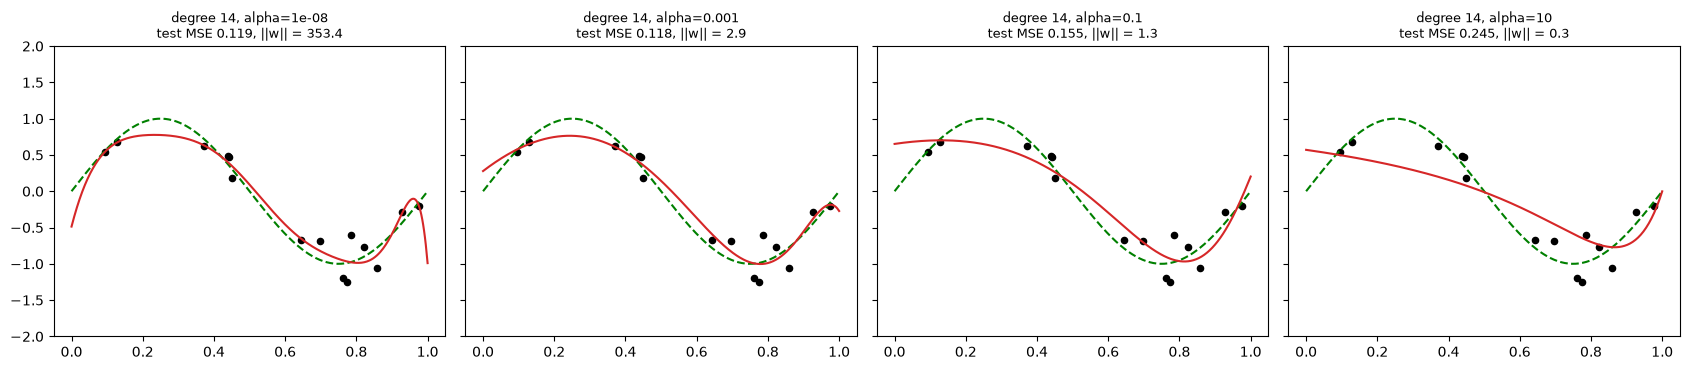

In [15]:
# Ridge tames the overfitted degree-14 polynomial from Section 6
fig, axes = plt.subplots(1, 4, figsize=(17, 3.8), sharey=True)
for ax, alpha in zip(axes, [1e-8, 1e-3, 1e-1, 10]):
    m = poly_model(14, alpha=alpha).fit(x_tr[:, None], y_tr)
    te = np.mean((m.predict(x_te[:, None]) - y_te)**2)
    ax.plot(grid, f_true(grid), "g--"); ax.plot(grid, m.predict(grid[:, None]), "C3")
    ax.scatter(x_tr, y_tr, s=20, color="k"); ax.set_ylim(-2, 2)
    ax.set_title(f"degree 14, alpha={alpha:g}\ntest MSE {te:.3f}, ||w|| = {np.linalg.norm(m[-1].coef_):.1f}", fontsize=9)
plt.tight_layout(); plt.show()

## 9. Lasso regression

### 9.1 Objective and sparsity

The Lasso (Tibshirani, 1996) uses an $\ell_1$ penalty:
$$J_{\text{lasso}}(w) = \frac{1}{2n}\|y - Xw\|_2^2 + \alpha\|w\|_1 .$$
It is convex but **not differentiable** at $w_j=0$, and it has no closed form. Its key property is **sparsity**: for
large enough $\alpha$ many coefficients are *exactly* zero, performing feature selection.

*Geometric intuition.* Equivalently minimize the squared error subject to $\|w\|_1\le t$. The elliptical contours of the
squared error typically first touch the diamond-shaped $\ell_1$ ball at a **corner**, where some coordinates are zero; the
round $\ell_2$ ball has no corners, so Ridge shrinks but rarely zeroes coefficients.

*Probabilistic view.* The Lasso is the MAP estimate under a **Laplace prior** $p(w_j)\propto e^{-|w_j|/b}$, which has
a sharp peak at 0.

### 9.2 Coordinate descent and soft-thresholding

Minimize over one coordinate $w_j$ with the others fixed. Let $r^{(j)} = y - \sum_{k\ne j}x_k w_k$ be the partial residual,
$\rho_j = \frac1n x_j^\top r^{(j)}$ and $z_j = \frac1n x_j^\top x_j$. The one-dimensional problem
$\frac{1}{2n}\|r^{(j)} - x_j w_j\|^2 + \alpha|w_j|$ has subgradient optimality condition
$0\in z_j w_j - \rho_j + \alpha\,\partial|w_j|$, with $\partial|w|=\{\operatorname{sign}(w)\}$ for $w\ne0$ and $[-1,1]$ at $0$. Solving:
$$w_j \leftarrow \frac{S(\rho_j,\alpha)}{z_j},\qquad S(\rho,\alpha) = \operatorname{sign}(\rho)\max(|\rho|-\alpha,\,0)\quad(\text{soft-thresholding}).$$
If the correlation $|\rho_j|$ of feature $j$ with the current residual is below $\alpha$, the coefficient is set exactly to 0.
Cycling through coordinates converges to the global minimum (the non-smooth part is separable). This is the algorithm
behind scikit-learn's `Lasso` and glmnet; with warm starts along a decreasing sequence of $\alpha$ it computes whole
**regularization paths** cheaply. The smallest $\alpha$ giving $w=0$ is $\alpha_{\max} = \frac1n\|X^\top y\|_\infty$ (centred data).

In [16]:
def soft_threshold(rho, alpha):
    return np.sign(rho) * np.maximum(np.abs(rho) - alpha, 0.0)

def lasso_cd(X, y, alpha, n_iters=1000, tol=1e-10, w0=None):
    # Coordinate descent for (1/2n)||y - Xw - b||^2 + alpha ||w||_1 (intercept handled by centering)
    x_mean, y_mean = X.mean(0), y.mean()
    Xc, yc = X - x_mean, y - y_mean
    n, d = Xc.shape
    z = (Xc**2).sum(0) / n
    w = np.zeros(d) if w0 is None else w0.copy()
    r = yc - Xc @ w                                    # full residual, updated incrementally
    for it in range(n_iters):
        max_change = 0.0
        for j in range(d):
            r += Xc[:, j] * w[j]                       # partial residual r^(j)
            rho = Xc[:, j] @ r / n
            w_new = soft_threshold(rho, alpha) / z[j]
            r -= Xc[:, j] * w_new
            max_change = max(max_change, abs(w_new - w[j])); w[j] = w_new
        if max_change < tol:
            break
    return w, y_mean - x_mean @ w, it + 1

for alpha in [0.1, 1.0, 5.0]:
    w, b, iters = lasso_cd(X_train, y_train, alpha)
    sk = Lasso(alpha=alpha, tol=1e-12, max_iter=100_000).fit(X_train, y_train)
    print(f"alpha={alpha:4.1f}: {iters:4d} sweeps, max|w - w_sklearn| = {np.abs(w - sk.coef_).max():.1e}, "
          f"nonzeros = {np.sum(w != 0)}/10")
w5, _, _ = lasso_cd(X_train, y_train, 5.0)
print("alpha=5 selected features:", [f for f, c in zip(feature_names, w5) if c != 0])
alpha_max = np.max(np.abs((X_train - X_train.mean(0)).T @ (y_train - y_train.mean()))) / len(y_train)
print(f"alpha_max = {alpha_max:.2f}; nonzeros at 1.001*alpha_max: {np.sum(lasso_cd(X_train, y_train, 1.001 * alpha_max)[0] != 0)}, "
      f"at 0.95*alpha_max: {np.sum(lasso_cd(X_train, y_train, 0.95 * alpha_max)[0] != 0)}")

alpha= 0.1:  469 sweeps, max|w - w_sklearn| = 1.1e-09, nonzeros = 9/10
alpha= 1.0:  192 sweeps, max|w - w_sklearn| = 5.5e-10, nonzeros = 9/10
alpha= 5.0:   28 sweeps, max|w - w_sklearn| = 4.0e-11, nonzeros = 5/10
alpha=5 selected features: ['sex', 'bmi', 'bp', 's3', 's5']
alpha_max = 45.97; nonzeros at 1.001*alpha_max: 0, at 0.95*alpha_max: 1


max deviation of our Lasso path from sklearn's lasso_path: 0.0


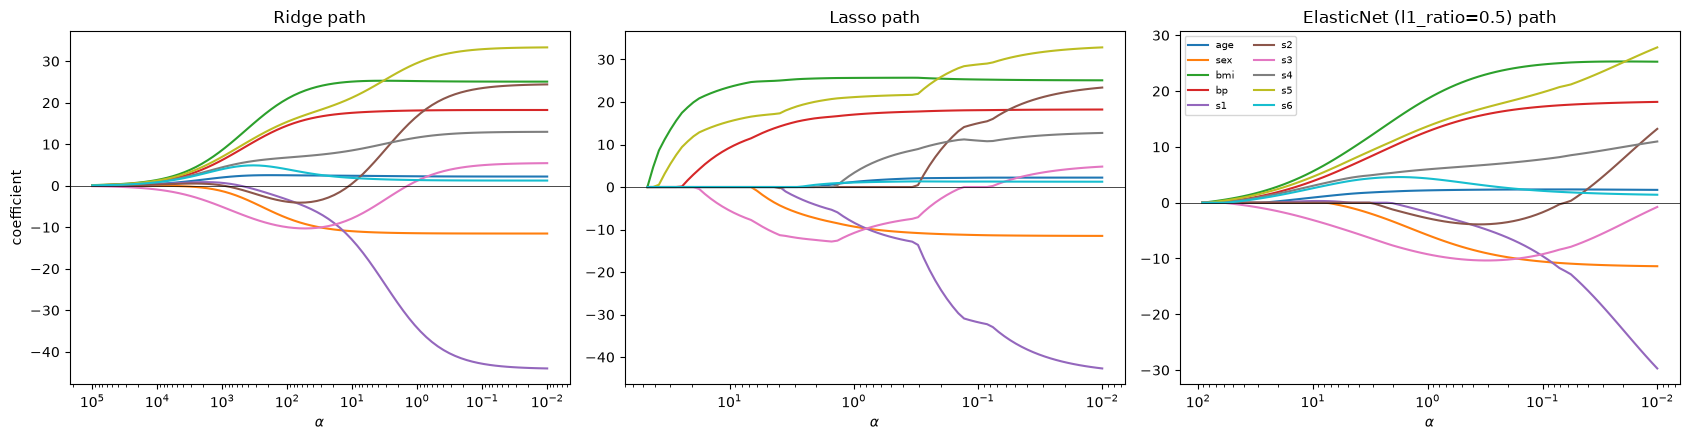

In [17]:
# Regularization paths: Ridge vs Lasso vs ElasticNet (standardized diabetes features)
Xc_tr = X_train - X_train.mean(0); yc_tr = y_train - y_train.mean()
alphas_l, coefs_l, _ = lasso_path(Xc_tr, yc_tr, alphas=np.logspace(-2, np.log10(alpha_max), 80), tol=1e-12, max_iter=100_000)
alphas_e, coefs_e, _ = enet_path(Xc_tr, yc_tr, l1_ratio=0.5, alphas=np.logspace(-2, np.log10(2 * alpha_max), 80))
alphas_r = np.logspace(-2, 5, 80)
coefs_r = np.array([ridge_fit(X_train, y_train, a)[0] for a in alphas_r]).T

# Our own coordinate-descent path (warm starts) for one check
w_prev = np.zeros(10); our_path = []
for a in alphas_l:                                     # alphas are returned in decreasing order
    w_prev, _, _ = lasso_cd(X_train, y_train, a, n_iters=20_000, w0=w_prev); our_path.append(w_prev)
print("max deviation of our Lasso path from sklearn's lasso_path:", np.abs(np.array(our_path).T - coefs_l).max().round(4))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, al, co, title in [(axes[0], alphas_r, coefs_r, "Ridge"), (axes[1], alphas_l, coefs_l, "Lasso"),
                          (axes[2], alphas_e, coefs_e, "ElasticNet (l1_ratio=0.5)")]:
    for j in range(10):
        ax.semilogx(al, co[j], label=feature_names[j])
    ax.axhline(0, color="k", lw=0.5); ax.set_xlabel(r"$\alpha$"); ax.set_title(f"{title} path"); ax.invert_xaxis()
axes[0].set_ylabel("coefficient"); axes[2].legend(fontsize=7, loc="upper left", ncol=2)
plt.tight_layout(); plt.show()

Reading the paths from left (strong regularization) to right (weak): Ridge coefficients shrink smoothly and all become
nonzero at once; Lasso coefficients **enter one at a time** (piecewise-linear paths, cf. the LARS algorithm), `bmi` and
`s5` first — a ranking of feature importance. At the right end both approach the OLS solution.

### 9.3 Choosing $\alpha$ by cross-validation

The regularization strength is a hyperparameter: pick it by K-fold cross-validation on the training data (details in
the model-selection lecture), then report test performance once.

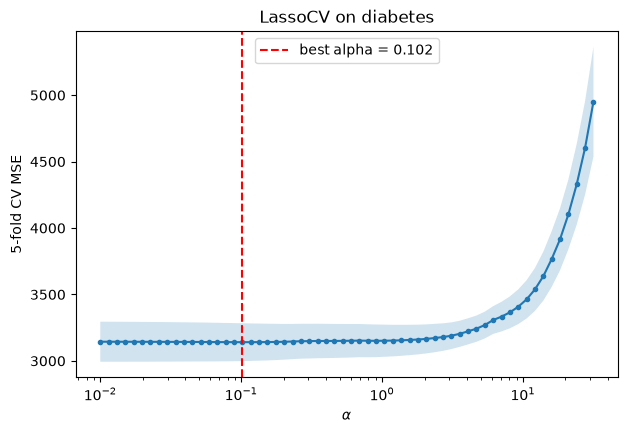

,MSE,RMSE,MAE,R2,nonzero coefs
OLS,2848.311,53.370,41.549,0.485,10.0
Ridge (alpha=10),2830.691,53.204,41.459,0.488,10.0
Lasso (alpha=0.10),2838.794,53.280,41.484,0.487,9.0


In [18]:
lcv = LassoCV(cv=5, alphas=np.logspace(-2, 1.5, 60), max_iter=50_000).fit(X_train, y_train)
mse_path = lcv.mse_path_.mean(1); se_path = lcv.mse_path_.std(1) / np.sqrt(lcv.mse_path_.shape[1])
plt.semilogx(lcv.alphas_, mse_path, "o-", ms=3)
plt.fill_between(lcv.alphas_, mse_path - se_path, mse_path + se_path, alpha=0.2)
plt.axvline(lcv.alpha_, color="r", ls="--", label=f"best alpha = {lcv.alpha_:.3f}")
plt.xlabel(r"$\alpha$"); plt.ylabel("5-fold CV MSE"); plt.title("LassoCV on diabetes"); plt.legend(); plt.show()

results = {}
for name, model in [("OLS", LinearRegression()), ("Ridge (alpha=10)", Ridge(alpha=10)),
                    (f"Lasso (alpha={lcv.alpha_:.2f})", Lasso(alpha=lcv.alpha_))]:
    model.fit(X_train, y_train)
    results[name] = {**metrics(y_test, model.predict(X_test)), "nonzero coefs": int(np.sum(model.coef_ != 0))}
pd.DataFrame(results).T.round(3)

## 10. ElasticNet

The Lasso has two weaknesses: with $d>n$ it selects at most $n$ features, and among a group of **highly correlated**
features it tends to pick one arbitrarily (unstable selection). The ElasticNet (Zou & Hastie, 2005) combines both penalties:
$$J_{\text{EN}}(w) = \frac{1}{2n}\|y - Xw\|^2 + \alpha\,\rho\,\|w\|_1 + \frac{\alpha(1-\rho)}{2}\|w\|_2^2,\qquad \rho = \texttt{l1\_ratio}\in[0,1].$$
The $\ell_2$ part makes the problem strictly convex and produces a **grouping effect** — correlated features receive similar
coefficients — while the $\ell_1$ part still gives sparsity. Coordinate descent carries over with the update
$w_j\leftarrow S(\rho_j, \alpha\rho)/(z_j + \alpha(1-\rho))$.

We illustrate the grouping effect with three nearly identical copies of one signal plus five pure-noise features.

In [19]:
def enet_cd(X, y, alpha, l1_ratio, n_iters=5000, tol=1e-10):
    Xc, yc = X - X.mean(0), y - y.mean(); n, d = Xc.shape
    z = (Xc**2).sum(0) / n; w = np.zeros(d); r = yc.copy()
    for _ in range(n_iters):
        max_change = 0.0
        for j in range(d):
            r += Xc[:, j] * w[j]
            w_new = soft_threshold(Xc[:, j] @ r / n, alpha * l1_ratio) / (z[j] + alpha * (1 - l1_ratio))
            r -= Xc[:, j] * w_new
            max_change = max(max_change, abs(w_new - w[j])); w[j] = w_new
        if max_change < tol:
            break
    return w

n = 200
signal = rng.normal(size=n)
X_corr = np.column_stack([signal + 0.05 * rng.normal(size=n) for _ in range(3)] + [rng.normal(size=(n, 5))])
y_corr = 3 * signal + rng.normal(0, 0.5, n)

lasso_c = Lasso(alpha=0.1).fit(X_corr, y_corr)
enet_c = ElasticNet(alpha=0.1, l1_ratio=0.3, tol=1e-12, max_iter=100_000).fit(X_corr, y_corr)
w_enet_ours = enet_cd(X_corr, y_corr, 0.1, 0.3)
print("ElasticNet from scratch vs sklearn, max abs diff:", np.abs(w_enet_ours - enet_c.coef_).max().round(6))
# Stability: refit on 20 bootstrap resamples and look at how the weight is split among the three copies
spread = {"Lasso": [], "ElasticNet": []}
for b in range(20):
    idx = rng.integers(0, n, n)
    spread["Lasso"].append(Lasso(alpha=0.1).fit(X_corr[idx], y_corr[idx]).coef_[:3])
    spread["ElasticNet"].append(ElasticNet(alpha=0.1, l1_ratio=0.3).fit(X_corr[idx], y_corr[idx]).coef_[:3])
for k, v in spread.items():
    v = np.array(v)
    print(f"{k:10s}: bootstrap std of each copy's coefficient = {v.std(0).round(3)}, "
          f"copy coefficients over all resamples range {v.min():.2f} .. {v.max():.2f}")
pd.DataFrame({"Lasso": lasso_c.coef_, "ElasticNet": enet_c.coef_},
             index=[f"copy{i+1}" for i in range(3)] + [f"noise{i+1}" for i in range(5)]).round(3).T

ElasticNet from scratch vs sklearn, max abs diff: 0.0
Lasso     : bootstrap std of each copy's coefficient = [0.494 0.64  0.534], copy coefficients over all resamples range 0.00 .. 2.26
ElasticNet: bootstrap std of each copy's coefficient = [0.019 0.028 0.021], copy coefficients over all resamples range 0.90 .. 1.03


,copy1,copy2,copy3,noise1,noise2,noise3,noise4,noise5
Lasso,1.051,0.598,1.255,0.0,-0.0,0.0,0.0,-0.0
ElasticNet,0.973,0.956,0.978,0.0,-0.0,0.0,0.0,-0.0


Both methods zero out the noise features, but the Lasso splits the weight among the three copies **unevenly and
unstably** — the split changes substantially from one bootstrap resample to the next (and with even stronger
correlation or larger $\alpha$ it drops copies entirely). The ElasticNet assigns nearly equal, stable coefficients to
the correlated group: the grouping effect.

### 10.1 Geometry of the penalties

The figure shows contours of a least-squares loss together with the $\ell_1$, $\ell_2$ and ElasticNet constraint regions
of equal "size". The constrained solution is where the smallest loss contour touches the region: for $\ell_1$ this happens
at a corner on an axis (a sparse solution).

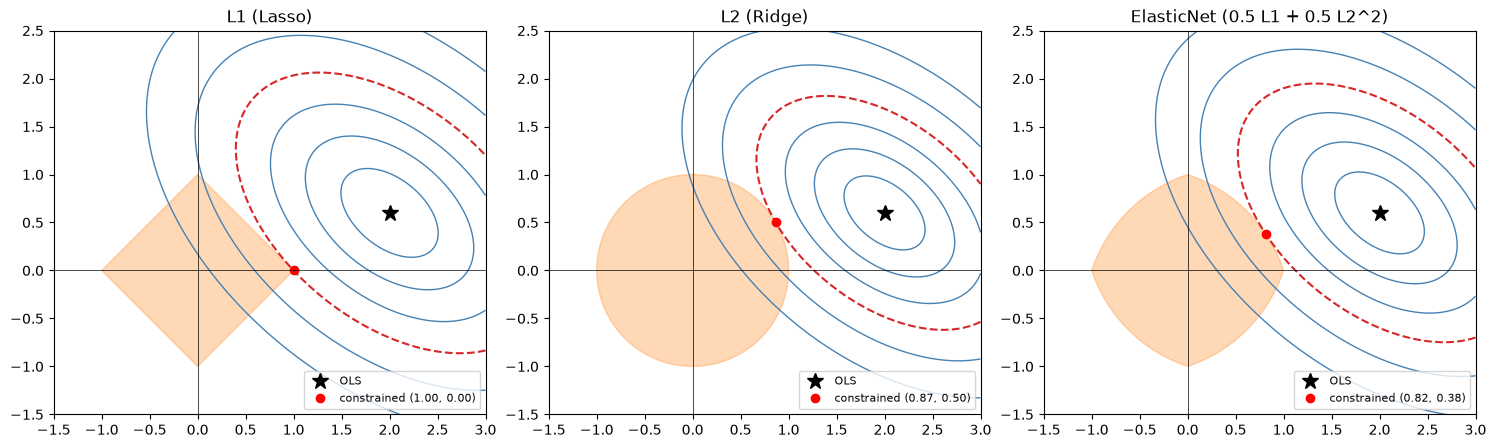

In [20]:
# Least-squares loss centred at w_ols with correlated curvature; find constrained optimum on each ball boundary
w_ols = np.array([2.0, 0.6]); Hq = np.array([[1.0, 0.5], [0.5, 1.2]])
loss = lambda W: np.einsum("...i,ij,...j->...", W - w_ols, Hq, W - w_ols)
g1, g2 = np.meshgrid(np.linspace(-1.5, 3, 300), np.linspace(-1.5, 2.5, 300))
Lgrid = loss(np.stack([g1, g2], -1))
t = np.linspace(0, 2 * np.pi, 4000); circ = np.stack([np.cos(t), np.sin(t)], 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, normfun) in zip(axes, [("L1 (Lasso)", lambda u: np.abs(u).sum(1)),
                                      ("L2 (Ridge)", lambda u: np.sqrt((u**2).sum(1))),
                                      ("ElasticNet (0.5 L1 + 0.5 L2^2)", lambda u: 0.5*np.abs(u).sum(1) + 0.5*(u**2).sum(1))]):
    # boundary of {w : penalty(w) <= 1}: rescale each direction; for EN solve 0.5 s^2 a + 0.5 s b = 1 for s
    if name.startswith("Elastic"):
        a, b = (circ**2).sum(1), np.abs(circ).sum(1); s = (-0.5 * b + np.sqrt(0.25 * b**2 + 2 * a)) / a
    else:
        s = 1 / normfun(circ)
    boundary = circ * s[:, None]
    w_c = boundary[np.argmin(loss(boundary))]
    ax.contour(g1, g2, Lgrid, levels=loss(w_c) * np.array([0.1, 0.3, 0.6, 1.6, 2.5]), colors="steelblue", linewidths=1)
    ax.contour(g1, g2, Lgrid, levels=[loss(w_c)], colors="C3", linestyles="--")      # the touching contour
    ax.fill(boundary[:, 0], boundary[:, 1], alpha=0.3, color="C1")
    ax.plot(*w_ols, "k*", ms=12, label="OLS"); ax.plot(*w_c, "ro", label=f"constrained ({w_c[0]:.2f}, {w_c[1]:.2f})")
    ax.axhline(0, color="k", lw=0.5); ax.axvline(0, color="k", lw=0.5)
    ax.set_aspect("equal"); ax.set_title(name); ax.legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

## 11. Pitfalls & practical tips

- **Scale before regularizing.** Ridge/Lasso/ElasticNet penalize all coefficients equally, so unscaled features are
  penalized inconsistently. Put a `StandardScaler` in a `Pipeline` (fitted on training data only).
- **Do not penalize the intercept.** Center the data (scikit-learn does this with `fit_intercept=True`).
- **Solve, don't invert**: prefer `lstsq`/QR/Cholesky; forming $(X^\top X)^{-1}$ squares the condition number.
- **Collinearity** makes OLS coefficients unstable and uninterpretable (huge standard errors) even when predictions are
  fine. Ridge stabilizes them; Lasso picks arbitrarily among correlated features; ElasticNet groups them.
- **Coefficients are not causal effects**, and Lasso-selected features are not necessarily the "true" ones, especially
  with correlated inputs. Check stability across bootstrap samples.
- **Know the parametrization**: `Ridge(alpha)` has no $1/n$ factor while `Lasso`/`ElasticNet` do, so the same numeric
  alpha means different things; scikit-learn's `alpha` is often called $\lambda$ in textbooks, and glmnet's `alpha` is the mixing parameter.
- **Tune $\alpha$ by cross-validation** on the training set (`RidgeCV`, `LassoCV`, `ElasticNetCV`); never on the test set.
- **Check residual plots**: structure (curvature, funnel shapes) signals a misspecified model or heteroscedastic noise.
- $R^2$ on the training set always increases with more features; report test-set metrics, and RMSE/MAE in the units of $y$.
- For GD/SGD: standardize, use $\eta\le 1/L$ for batch GD, decaying steps for SGD, and monitor the training loss.

## 12. Exercises

**Exercise 1 (pen and paper — OLS properties).** Show that (a) the residuals of OLS with an intercept sum to zero,
(b) $\hat\theta$ is unbiased under $y = X\theta+\varepsilon$, $\mathbb{E}\varepsilon=0$, and
(c) $\mathrm{Cov}[\hat\theta] = \sigma^2(X^\top X)^{-1}$ when $\mathrm{Cov}[\varepsilon]=\sigma^2 I$.

**Exercise 2 (pen and paper — Ridge).** (a) Show that Ridge regression equals OLS on the augmented data
$\tilde X = \begin{pmatrix}X\\ \sqrt{\alpha}I\end{pmatrix}$, $\tilde y = \begin{pmatrix}y\\0\end{pmatrix}$.
(b) For orthonormal design $X^\top X = I$, express $\hat w_{\text{ridge}}$ and $\hat w_{\text{lasso}}$ (with the
$\frac12\|y-Xw\|^2+\alpha\|w\|_1$ scaling) in terms of $\hat w_{\text{OLS}}$ and sketch both as functions of $\hat w_{\text{OLS},j}$.

**Exercise 3 (pen and paper — bias–variance for Ridge).** For fixed design, show
$\mathbb{E}[\hat w_{\text{ridge}}] = (X^\top X+\alpha I)^{-1}X^\top X\,w$ and
$\mathrm{Cov}[\hat w_{\text{ridge}}] = \sigma^2 (X^\top X+\alpha I)^{-1}X^\top X(X^\top X+\alpha I)^{-1}$.
Conclude that the bias increases and the variance decreases with $\alpha$.

**Exercise 4 (coding — gradient descent for Ridge and Lasso).** Implement batch GD for the Ridge objective (checking
against `ridge_fit`) and **proximal gradient descent** (ISTA) for the Lasso,
$w\leftarrow S(w - \eta\nabla f(w),\ \eta\alpha)$, and compare its convergence with `lasso_cd` on the diabetes data.

**Exercise 5 (coding — polynomial model selection).** On the synthetic sine data, use 5-fold cross-validation on the
training set to choose (a) the polynomial degree for OLS and (b) $\alpha$ for Ridge with degree 14. Compare the test MSE of
both choices over 50 random training sets of size 15.

**Exercise 6 (coding — Lasso stability).** Fit `LassoCV` on 100 bootstrap resamples of the diabetes training data and
report, for each feature, the fraction of resamples in which it is selected. Which features are stable?

In [21]:
# Exercise 4 — starter code
def ridge_gd(X, y, alpha, lr, n_iters):
    # TODO: minimize ||y - Xw - b||^2 + alpha ||w||^2 by gradient descent (do not penalize b)
    w, b = np.zeros(X.shape[1]), 0.0
    return w, b

def lasso_ista(X, y, alpha, n_iters):
    # TODO: proximal gradient: gradient step on (1/2n)||y - Xw||^2, then soft_threshold with eta*alpha
    # choose eta = 1/L with L = largest eigenvalue of X^T X / n (after centering)
    return None

In [22]:
# Exercise 5 — starter code
from sklearn.model_selection import cross_val_score, KFold

def choose_degree_cv(x, y, degrees=range(1, 13), k=5):
    # TODO: return the degree with the smallest mean CV MSE
    # hint: cross_val_score(poly_model(d), x[:, None], y, cv=KFold(k, shuffle=True, random_state=0),
    #                       scoring="neg_mean_squared_error")
    return None

In [23]:
# Exercise 6 — starter code
def lasso_selection_frequency(X, y, n_boot=100, seed=0):
    r = np.random.default_rng(seed)
    counts = np.zeros(X.shape[1])
    # TODO: for each bootstrap resample idx = r.integers(0, len(y), len(y)), fit LassoCV and count nonzero coefs
    return counts / n_boot

## 13. Summary

- Linear regression = linear in the parameters. OLS minimizes $\|y-X\theta\|^2$; the normal equations
  $X^\top X\theta = X^\top y$ express orthogonality of residuals to the column space (projection by the hat matrix).
- Least squares is the MLE under i.i.d. Gaussian noise; the MLE of the noise variance is the mean squared residual.
- Closed form costs $O(nd^2)$; batch GD $O(nd)$ per step with rate set by the condition number; mini-batch SGD makes
  cheap noisy steps and wins per epoch early on. Standardizing features improves conditioning dramatically.
- Test error = bias$^2$ + variance + noise. Flexible models (high-degree polynomials) have low bias and high variance.
- Ridge $= (X^\top X+\alpha I)^{-1}X^\top y$ shrinks along low-variance singular directions and is MAP with a Gaussian prior.
- Lasso ($\ell_1$, Laplace prior) yields sparse solutions via soft-thresholding coordinate descent; ElasticNet mixes
  $\ell_1$ and $\ell_2$ for sparsity plus grouping of correlated features. Regularization paths and CV guide the choice of $\alpha$.
- Report MSE/RMSE/MAE/$R^2$ on held-out data; $R^2$ can be negative out of sample.

## Further reading

- James, Witten, Hastie, Tibshirani, Taylor — *ISLP*, Ch. 3 (linear regression) and Ch. 6 (Ridge, Lasso, model selection).
- Hastie, Tibshirani, Friedman — *ESL*, Ch. 3 (3.2 least squares, 3.4 shrinkage methods, LAR) and Ch. 7.3 (bias–variance).
- Bishop — *PRML*, Ch. 1.1 (polynomial curve fitting), Ch. 3.1–3.2 (linear basis models, bias–variance).
- Murphy — *Probabilistic Machine Learning: An Introduction*, Ch. 11 (linear regression, Ridge, Lasso, ElasticNet).
- Géron — *Hands-On Machine Learning*, Ch. 4 (training models: normal equation, GD variants, regularized models).
- Hastie, Tibshirani, Wainwright — *Statistical Learning with Sparsity* (2015), Ch. 2–5.
- Hoerl, Kennard (1970), "Ridge Regression: Biased Estimation for Nonorthogonal Problems", *Technometrics*.
- Tibshirani (1996), "Regression Shrinkage and Selection via the Lasso", *JRSS B*.
- Efron, Hastie, Johnstone, Tibshirani (2004), "Least Angle Regression", *Annals of Statistics*.
- Zou, Hastie (2005), "Regularization and Variable Selection via the Elastic Net", *JRSS B*.
- Friedman, Hastie, Tibshirani (2010), "Regularization Paths for Generalized Linear Models via Coordinate Descent", *J. Stat. Software*.
- Geman, Bienenstock, Doursat (1992), "Neural Networks and the Bias/Variance Dilemma", *Neural Computation*.